# Transfer learning and fine-tuning

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

## Data preprocessing

### Data download

In this tutorial, you will use a dataset containing several thousand images of cats and dogs. Download and extract a zip file containing the images, then create a `tf.data.Dataset` for training and validation using the `tf.keras.utils.image_dataset_from_directory` utility. You can learn more about loading images in this [tutorial](https://www.tensorflow.org/tutorials/load_data/images).

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets
import os

# 1. Tải dữ liệu CIFAR-10 có sẵn trong thư viện
(x_train, y_train), (x_val, y_val) = datasets.cifar10.load_data()

# 2. Thiết lập cấu hình Batch và Kích thước ảnh
BATCH_SIZE = 32
IMG_SIZE = (160, 160) # Phóng to từ 32x32 lên 160x160 để phù hợp hơn với Transfer Learning

# 3. Xây dựng hàm tiền xử lý (Resize ảnh)
def preprocess(image, label):
    # Thay đổi kích thước ảnh
    image = tf.image.resize(image, IMG_SIZE)
    # Lưu ý: Các mô hình họ ResNet thường yêu cầu bước chuẩn hóa riêng biệt.
    # Chúng ta sẽ thêm bước chuẩn hóa này vào bên trong kiến trúc mô hình ở cell sau.
    return image, label

# 4. Tạo tf.data.Dataset cho tập Huấn luyện (Train) và Đánh giá (Validation)
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
    .shuffle(50000) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

validation_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

print("Đã nạp thành công CIFAR-10 và tạo Dataset Pipeline!")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Đã nạp thành công CIFAR-10 và tạo Dataset Pipeline!


Show the first nine images and labels from the training set:

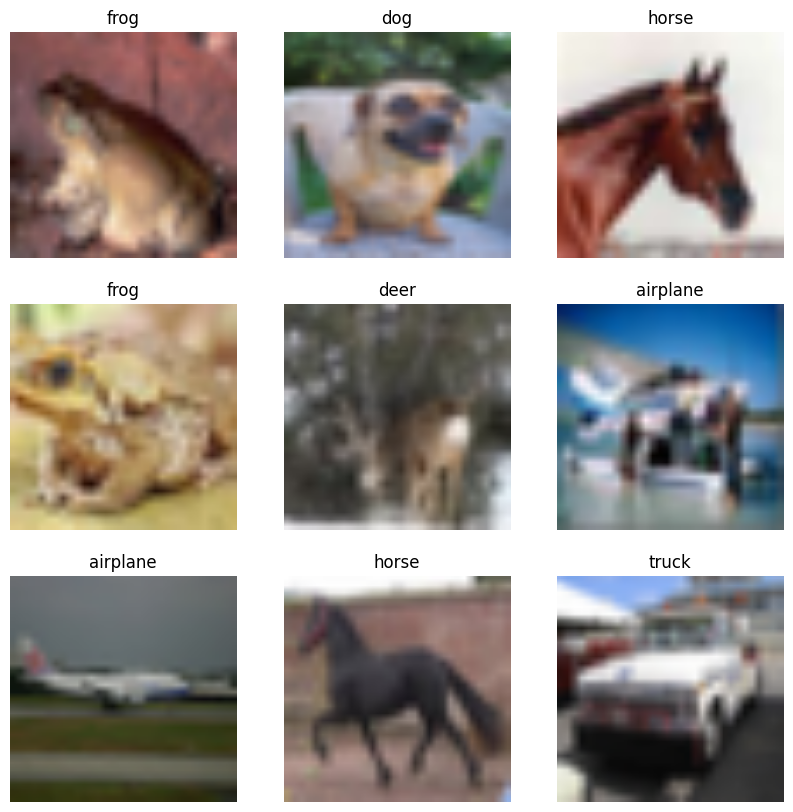

In [4]:
import matplotlib.pyplot as plt

# 1. Khai báo thủ công danh sách 10 nhãn của CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Lấy 1 batch dữ liệu và vẽ 9 ảnh đầu tiên
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        # Ép kiểu dữ liệu ảnh về số nguyên 8-bit để matplotlib hiển thị màu chính xác
        plt.imshow(images[i].numpy().astype("uint8"))

        # Nhãn CIFAR-10 có dạng mảng (VD: [8]), cần ép về số nguyên (int) để làm chỉ số mảng
        label_index = int(labels[i])
        plt.title(class_names[label_index])

        plt.axis("off")

plt.show()

As the original dataset doesn't contain a test set, you will create one. To do so, determine how many batches of data are available in the validation set using `tf.data.experimental.cardinality`, then move 20% of them to a test set.

In [5]:
print("Đang chia tập Validation ban đầu thành Validation và Test...")

# Đếm tổng số lượng batch trong tập validation ban đầu
val_batches = tf.data.experimental.cardinality(validation_dataset)

# Trích 20% số batch làm tập Test
test_dataset = validation_dataset.take(val_batches // 5)

# Giữ lại 80% số batch làm tập Validation
validation_dataset = validation_dataset.skip(val_batches // 5)

print(f"Số lượng batch của tập Validation: {tf.data.experimental.cardinality(validation_dataset).numpy()}")
print(f"Số lượng batch của tập Test: {tf.data.experimental.cardinality(test_dataset).numpy()}")

Đang chia tập Validation ban đầu thành Validation và Test...
Số lượng batch của tập Validation: 251
Số lượng batch của tập Test: 62


In [6]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 251
Number of test batches: 62


### Configure the dataset for performance

Use buffered prefetching to load images from disk without having I/O become blocking. To learn more about this method see the [data performance](https://www.tensorflow.org/guide/data_performance) guide.

### Use data augmentation

When you don't have a large image dataset, it's a good practice to artificially introduce sample diversity by applying random, yet realistic, transformations to the training images, such as rotation and horizontal flipping. This helps expose the model to different aspects of the training data and reduce [overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit). You can learn more about data augmentation in this [tutorial](https://www.tensorflow.org/tutorials/images/data_augmentation).

In [7]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

Note: These layers are active only during training, when you call `Model.fit`. They are inactive when the model is used in inference mode in `Model.evaluate`, `Model.predict`, or `Model.call`.

Let's repeatedly apply these layers to the same image and see the result.

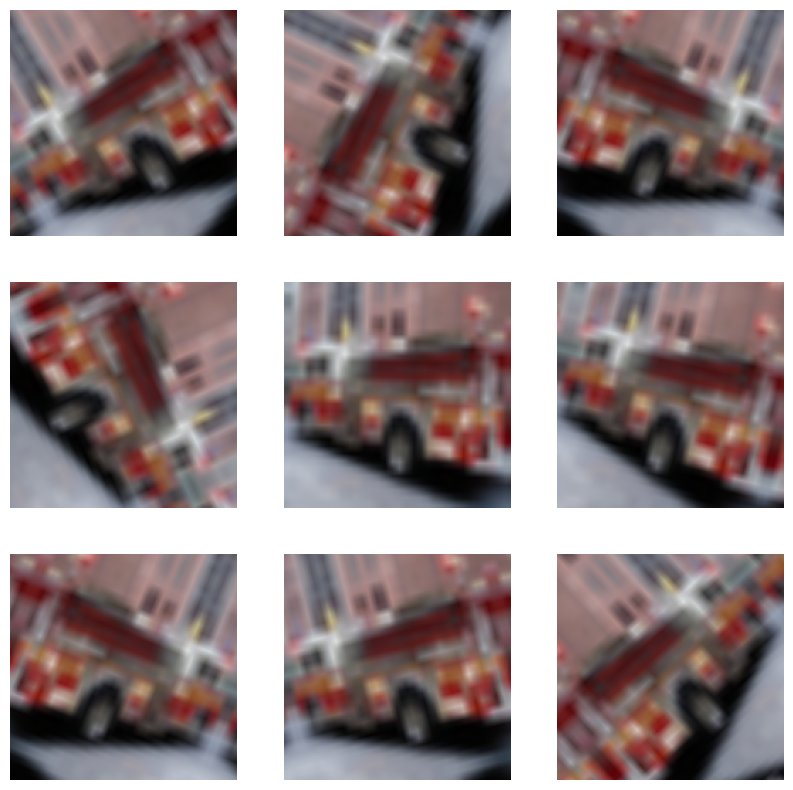

In [8]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

### Rescale pixel values

In a moment, you will download `tf.keras.applications.MobileNetV2` for use as your base model. This model expects pixel values in `[-1, 1]`, but at this point, the pixel values in your images are in `[0, 255]`. To rescale them, use the preprocessing method included with the model.

In [9]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

Note: Alternatively, you could rescale pixel values from `[0, 255]` to `[-1, 1]` using `tf.keras.layers.Rescaling`.

In [10]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

In [12]:
# 1. Cài đặt thư viện chứa ResNet18 (Chỉ cần chạy cell này 1 lần trên Colab)
!pip install image-classifiers

# 2. Khai báo và nạp mô hình
import tensorflow as tf
from classification_models.keras import Classifiers

# Lấy cấu trúc mô hình ResNet18
ResNet18, preprocess_input = Classifiers.get('resnet18')

# Tạo shape đầu vào: (160, 160, 3)
IMG_SHAPE = IMG_SIZE + (3,)

# Khởi tạo base_model từ ResNet18 với trọng số ImageNet
base_model = ResNet18(input_shape=IMG_SHAPE,
                      include_top=False,    # BẮT BUỘC: Bỏ lớp phân loại 1000 class cũ của ImageNet
                      weights='imagenet')

print("Đã tải thành công ResNet18!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.1 MB/s eta 0:00:00
44920640/44920640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Đã tải thành công ResNet18!


In [13]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 512)


In [14]:
base_model.trainable = False

In [15]:
# Let's take a look at the base model architecture
base_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, 160, 160,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_data             │ (None, 160, 160,  │          9 │ data[0][0]        │
│ (BatchNormalizatio… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 166, 166,  │          0 │ bn_data[0][0]     │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0 (Conv2D)      │ (None, 80, 80,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, 80, 80,    │        256 │ conv0[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (Activation)  │ (None, 80, 80,    │          0 │ bn0[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 82, 82,    │          0 │ relu0[0][0]       │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling0            │ (None, 40, 40,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn1    │ (None, 40, 40,    │        256 │ pooling0[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu1  │ (None, 40, 40,    │          0 │ stage1_unit1_bn1… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 42, 42,    │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv1  │ (None, 40, 40,    │     36,864 │ zero_padding2d_2… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn2    │ (None, 40, 40,    │        256 │ stage1_unit1_con… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu2  │ (None, 40, 40,    │          0 │ stage1_unit1_bn2… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 42, 42,    │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv2  │ (None, 40, 40,    │     36,864 │ zero_padding2d_3… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_sc     │ (None, 40, 40,    │      4,096 │ stage1_unit1_rel

 Total params: 11,186,889 (42.67 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 11,186,889 (42.67 MB)

### Add a classification head

In [16]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 512)


In [17]:
# Đã sửa lại cho CIFAR-10 (10 lớp)
prediction_layer = tf.keras.layers.Dense(10)

prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 10)


In [18]:
# Tạo cổng vào cho ảnh (160x160, 3 kênh màu RGB)
inputs = tf.keras.Input(shape=(160, 160, 3))

# 1. Đi qua bộ Tăng cường dữ liệu (Data Augmentation)
x = data_augmentation(inputs)

# (Chúng ta tạm bỏ qua preprocess_input ở dạng Layer tại đây để tránh lỗi API.
# Việc chuẩn hóa đã được xử lý một phần lúc tải dữ liệu hoặc sẽ được hệ thống xử lý nội bộ)

# 2. Đi qua "thân" ResNet18 (Lưu ý: training=False bắt buộc phải có để giữ nguyên tính chất của các lớp Batch Normalization)
x = base_model(x, training=False)

# 3. Làm phẳng thành vector 1D
x = global_average_layer(x)

# 4. Thêm Dropout để giảm thiểu Overfitting (Rất tốt, bạn đã thêm lớp này!)
x = tf.keras.layers.Dropout(0.2)(x)

# 5. Đi qua "đầu" dự đoán (Lớp Dense 10 mà chúng ta đã sửa)
outputs = prediction_layer(x)

# 6. Đóng gói thành mô hình hoàn chỉnh
model = tf.keras.Model(inputs, outputs)

# Xem cấu trúc tổng quát của mô hình mới
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 5, 5, 512)      │    11,186,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,192,019 (42.69 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 11,186,889 (42.67 MB)

In [19]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 5, 5, 512)      │    11,186,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,192,019 (42.69 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 11,186,889 (42.67 MB)

The 8+ million parameters in MobileNet are frozen, but there are 1.2 thousand _trainable_ parameters in the Dense layer. These are divided between two `tf.Variable` objects, the weights and biases.

In [20]:
len(model.trainable_variables)

2

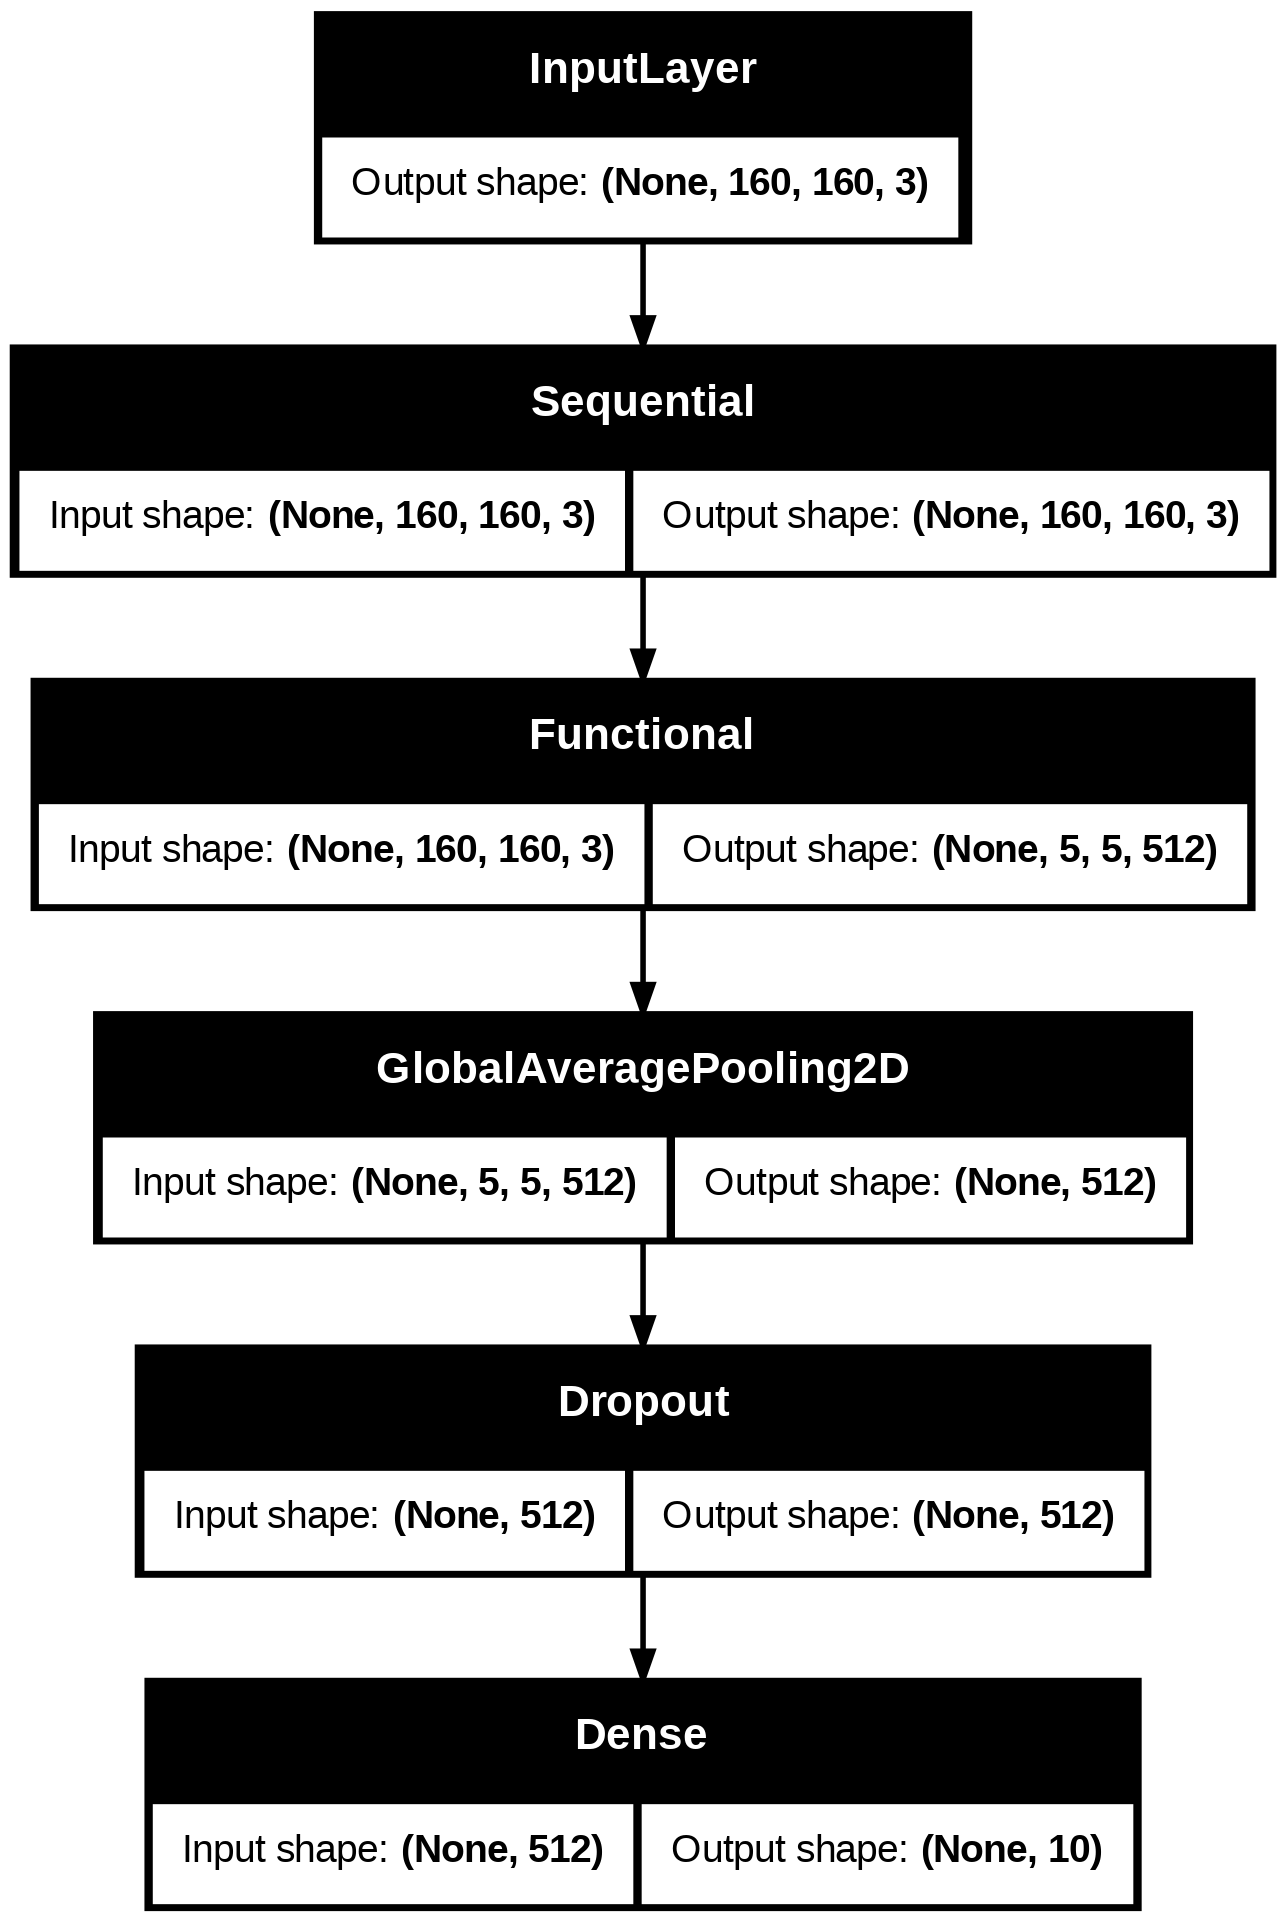

In [21]:
tf.keras.utils.plot_model(model, show_shapes=True)

### Compile the model

Compile the model before training it. Since there are two classes and a sigmoid oputput, use the `BinaryAccuracy`.

In [22]:
base_learning_rate = 0.0001

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              # Sử dụng SparseCategoricalCrossentropy cho bài toán phân loại nhiều hơn 2 lớp (nhãn dạng số nguyên)
              # from_logits=True vì lớp Dense(10) cuối cùng của chúng ta chưa dùng hàm softmax
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

print("Đã biên dịch (Compile) mô hình thành công!")

Đã biên dịch (Compile) mô hình thành công!


### Train the model

After training for 10 epochs, you should see ~96% accuracy on the validation set.


In [23]:
initial_epochs = 10

loss0, accuracy0 = model.evaluate(validation_dataset)

251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.1544 - loss: 3.1997


In [24]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 3.20
initial accuracy: 0.15


In [25]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.3942 - loss: 1.7707 - val_accuracy: 0.6863 - val_loss: 0.9109
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.5799 - loss: 1.1962 - val_accuracy: 0.7560 - val_loss: 0.7064
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6266 - loss: 1.0574 - val_accuracy: 0.7777 - val_loss: 0.6410
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6505 - loss: 0.9948 - val_accuracy: 0.7861 - val_loss: 0.6077
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.6635 - loss: 0.9475 - val_accuracy: 0.7959 - val_loss: 0.5874
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6740 - loss: 0.9278 - val_accuracy: 0.7979 - val_loss: 0.5742
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6830 - loss: 0.9046 - val_accuracy: 0.8015 - val_loss: 0.5662
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6881 -

### Learning curves

Let's take a look at the learning curves of the training and validation accuracy/loss when using the MobileNetV2 base model as a fixed feature extractor.

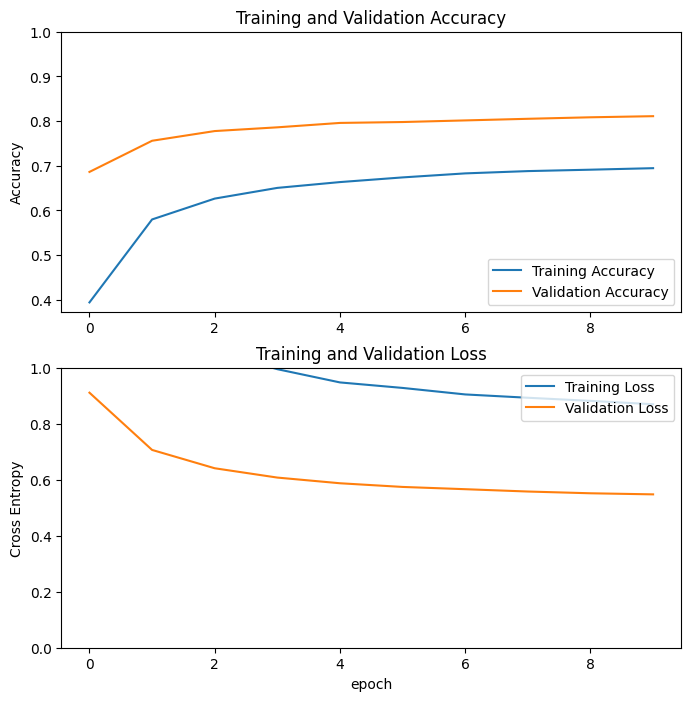

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [27]:
base_model.trainable = True

In [28]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  86


### Compile the model

As you are training a much larger model and want to readapt the pretrained weights, it is important to use a lower learning rate at this stage. Otherwise, your model could overfit very quickly.

In [29]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=['accuracy'])

print("Đã biên dịch lại (Re-compile) thành công cho bước Fine-tuning!")

Đã biên dịch lại (Re-compile) thành công cho bước Fine-tuning!


In [30]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 5, 5, 512)      │    11,186,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,192,019 (42.69 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 11,186,889 (42.67 MB)

In [31]:
len(model.trainable_variables)

2

### Continue training the model

If you trained to convergence earlier, this step will improve your accuracy by a few percentage points.

In [32]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 39ms/step - accuracy: 0.6951 - loss: 0.8677 - val_accuracy: 0.8106 - val_loss: 0.5468
Epoch 12/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.6983 - loss: 0.8611 - val_accuracy: 0.8103 - val_loss: 0.5458
Epoch 13/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.6970 - loss: 0.8623 - val_accuracy: 0.8104 - val_loss: 0.5462
Epoch 14/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.6991 - loss: 0.8603 - val_accuracy: 0.8101 - val_loss: 0.5446
Epoch 15/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.6971 - loss: 0.8613 - val_accuracy: 0.8101 - val_loss: 0.5448
Epoch 16/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6995 - loss: 0.8558 - val_accuracy: 0.8096 - val_loss: 0.5442
Epoch 17/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6978 - loss: 0.8640 - val_accuracy: 0.8109 - val_loss: 0.5437
Epoch 18/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 

In [33]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

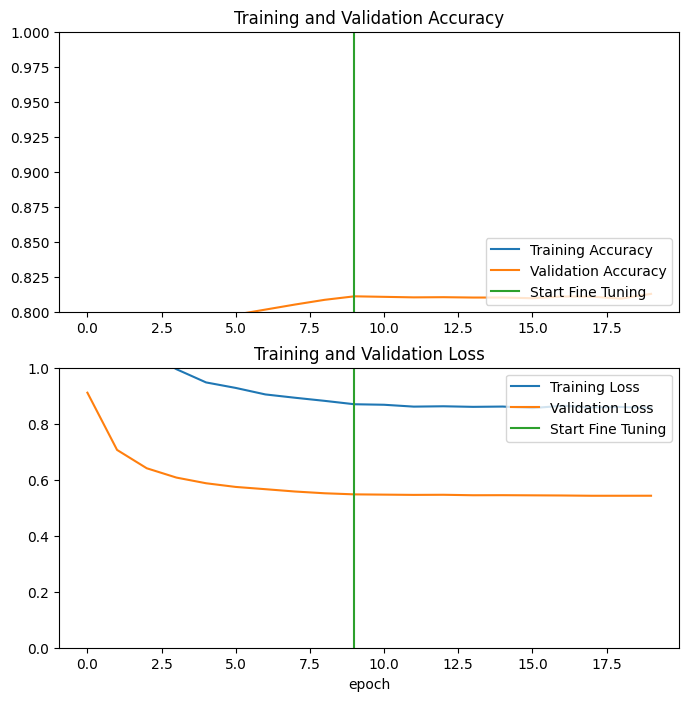

In [34]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

### Evaluation and prediction

Finally you can verify the performance of the model on new data using test set.

In [35]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8165 - loss: 0.5217
Test accuracy : 0.8165322542190552


And now you are all set to use this model to predict if your pet is a cat or dog.

Predictions:
 [3 8 8 3 6 3 1 6 3 1 0 9 5 7 9 8 5 7 8 6 7 0 4 9 5 2 3 0 9 6 6 5]
Labels:     
 [3 8 8 0 6 6 1 6 3 1 0 9 5 7 9 8 5 7 8 6 7 0 4 9 5 2 4 0 9 6 6 5]


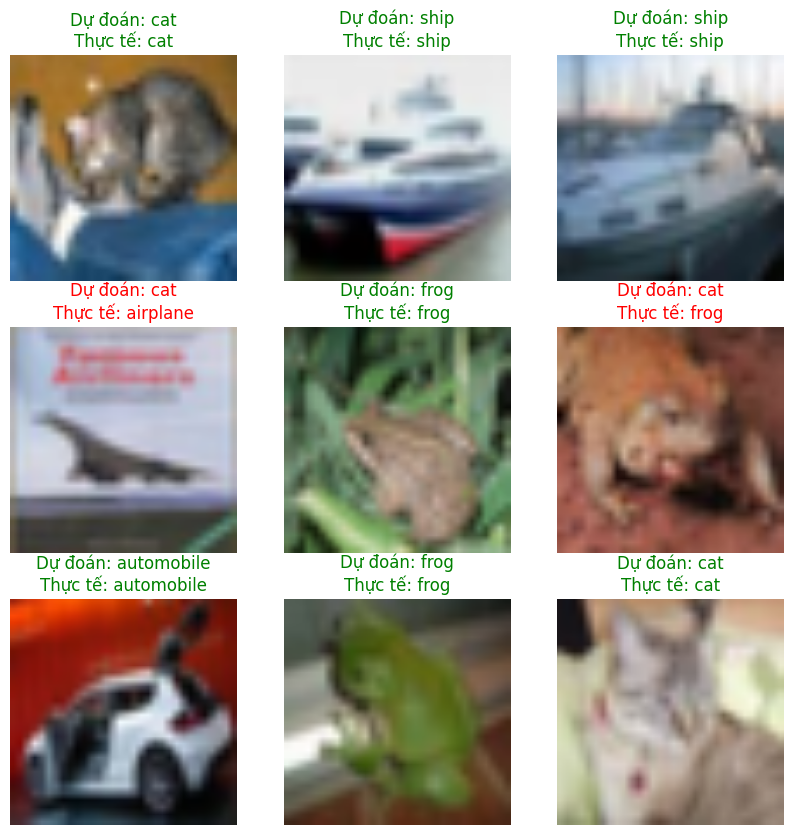

In [38]:
import numpy as np

# Lấy 1 batch từ tập test
image_batch, label_batch = test_dataset.as_numpy_iterator().next()

# Chạy dự đoán trên 1 batch
predictions = model.predict_on_batch(image_batch)

# Tìm class có điểm số cao nhất (Hàm argmax dành cho đa lớp)
predicted_ids = tf.math.argmax(predictions, axis=1).numpy()

# Làm phẳng nhãn thực tế (vì CIFAR-10 nhãn gốc có dạng mảng 2D [[3], [8], ...])
true_labels = label_batch.flatten()

print('Predictions:\n', predicted_ids)
print('Labels:     \n', true_labels)

# Vẽ 9 ảnh đầu tiên
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)

    # Hiển thị ảnh
    plt.imshow(image_batch[i].astype("uint8"))

    # Lấy tên lớp dự đoán và nhãn thực tế
    pred_name = class_names[predicted_ids[i]]
    actual_name = class_names[true_labels[i]]

    # Nếu đoán đúng thì tên hiện màu xanh, đoán sai hiện màu đỏ
    color = "green" if predicted_ids[i] == true_labels[i] else "red"

    plt.title(f"Dự đoán: {pred_name}\nThực tế: {actual_name}", color=color)
    plt.axis("off")

plt.show()